In [1]:
import numpy as np
import matplotlib.pyplot as plt
import json
from HARey.projections import stereo_polar

In [2]:
file_name = '/home/giacomo/Downloads/mw.json'

with open(file_name, 'r') as file:
    data = json.load(file)

In [3]:
luminosity_levels = [(data['features'][i]['geometry']['coordinates'][0]) for i in range(5)]
luminosity_levels = [[np.array(ring) for ring in rings] for rings in luminosity_levels]

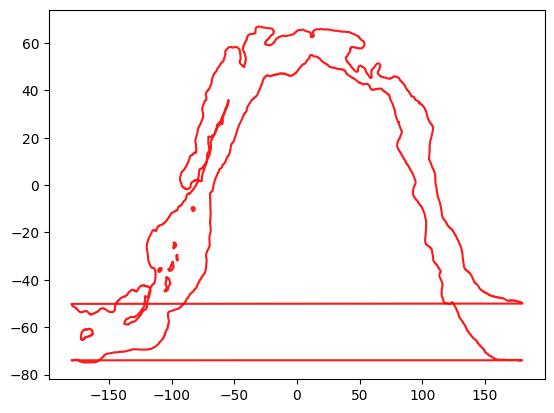

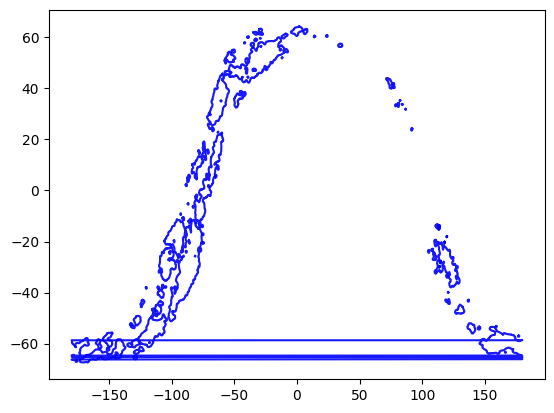

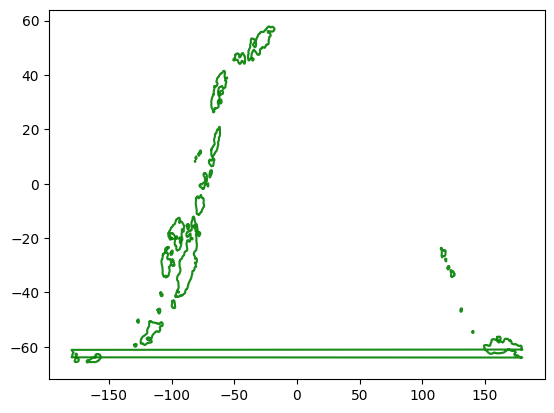

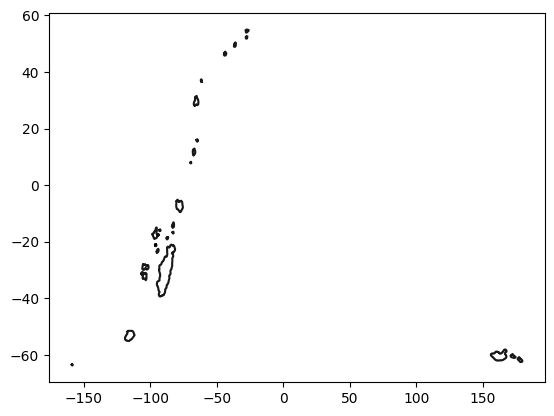

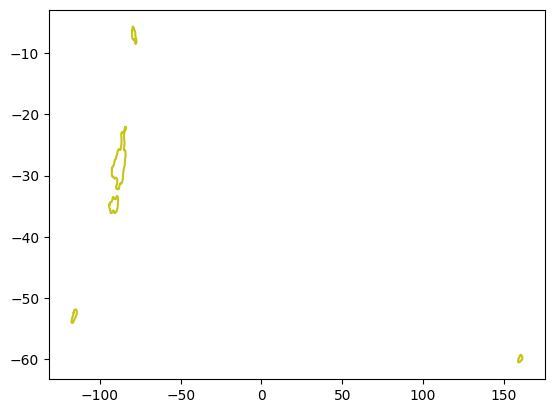

In [4]:
for level, color in zip(luminosity_levels, ['r', 'b', 'g', 'k', 'y']):
    for ring in level:
        x,y = zip(*ring)
        plt.plot(x,y, color, alpha=0.9)
    plt.show()

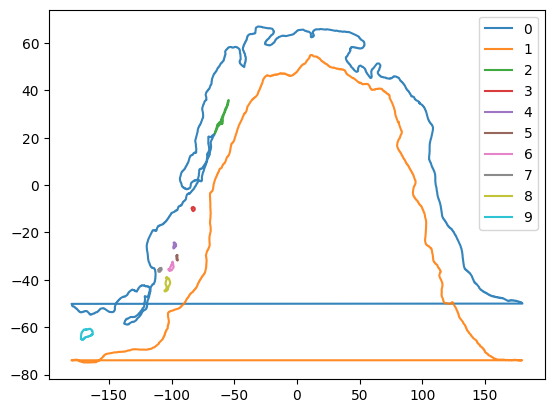

In [5]:
ext_ring = luminosity_levels[0]
for i, ring in enumerate(ext_ring):
    x,y = zip(*ring)
    plt.plot(x,y, alpha=0.9, label=f'{i}')
plt.legend()
plt.show()

In [6]:
def one_hot_encode(a):
    # Compute rising edges (consider also the first value if True)
    a_rising = np.r_[False, a]
    rising_edges = np.argwhere(a_rising[1:] & ~a_rising[:-1]).flatten()

    # Compute falling edges (consider also the last value if True)
    a_falling = np.r_[a, False]
    falling_edges = np.argwhere(~a_falling[1:] & a_falling[:-1]).flatten() + 1

    masks = []
    # For each region between edges, return a mask of that region
    for rising, falling in zip(rising_edges, falling_edges):
        # Extend the right border by one
        mask = np.zeros_like(a).astype(bool)
        mask[rising:falling] = True
        masks.append(mask)

    return masks

In [7]:
one_hot_encode(np.array([0,1,1,1,0,0,0,1,1,1]).astype('bool'))

[array([False,  True,  True,  True, False, False, False, False, False,
        False]),
 array([False, False, False, False, False, False, False,  True,  True,
         True])]

In [8]:
def get_segments(ring, borders):
    
    inside = lambda x,y : (x >= borders[0]) & (x<= borders[1])
    segments = []
    for mask in one_hot_encode(inside(*ring.T)):
        segment = ring[mask]

        get_closest_border = lambda x: borders[0] if np.abs(x[0] - borders[0]) < np.abs(x[0] - borders[1]) else borders[1]
        
        if not mask[0]:
            start = segment[0]
            start_border = get_closest_border(start)        
            connect_start = np.array((start_border, start[1])).reshape((1,2))
            segment = np.concatenate([connect_start, segment])

        if not mask[-1]:
            end = segment[-1]
            end_border = get_closest_border(end)        
            connect_end = np.array((end_border, end[1])).reshape((1,2))  
            segment = np.concatenate([segment, connect_end])  
        
        segments.append(segment)
        
    return segments

In [9]:
def merge_segments(segments):
    merged_segments = []
    used = [False]*len(segments)

    for i in range(len(segments)):
        for j in range(len(segments)):
            if np.all(segments[i][0] == segments[j][-1]):
                used[i], used[j] = True, True
                merged_segments.append(np.concatenate([segments[j], segments[i]]))

        if not used[i]:
            merged_segments.append(segments[i])
            
    return merged_segments
        

In [10]:
first_ring = np.concatenate([ext_ring[0], ext_ring[1][::-1], ext_ring[0][0].reshape(1,2)])

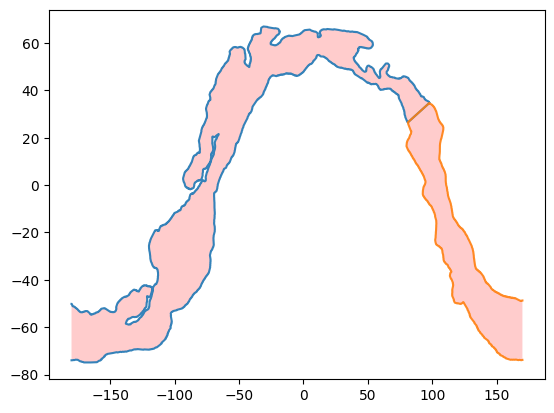

In [11]:
for segment in merge_segments(get_segments(first_ring, (-180,170))):
    x,y = zip(*segment)
    plt.plot(x,y, alpha=0.9)
    plt.fill(x,y, 'r', alpha=0.2)
    
plt.show()

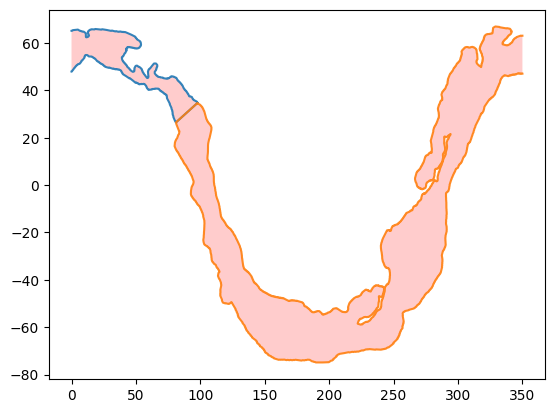

In [12]:
x, y = first_ring[:,0], first_ring[:,1]
x = (x)%360
first_ring = np.array((x,y)).T

for segment in merge_segments(get_segments(first_ring, (0,350))):
    x,y = zip(*segment)
    plt.plot(x,y, alpha=0.9)
    plt.fill(x,y, 'r', alpha=0.2)
    
plt.show()

# From the top again, adding more levels

In [13]:
def join_segs(segments, joins, reverse=[]):
    rings = []
    for ring_indexes in joins:
        ring = []
        for index in ring_indexes:
            if index in reverse:
                ring.extend(list(segments[index][::-1]))
            else:
                ring.extend(list(segments[index]))

        rings.append(np.array(ring))

    return rings

In [14]:
shapes = []
second_shapes = []

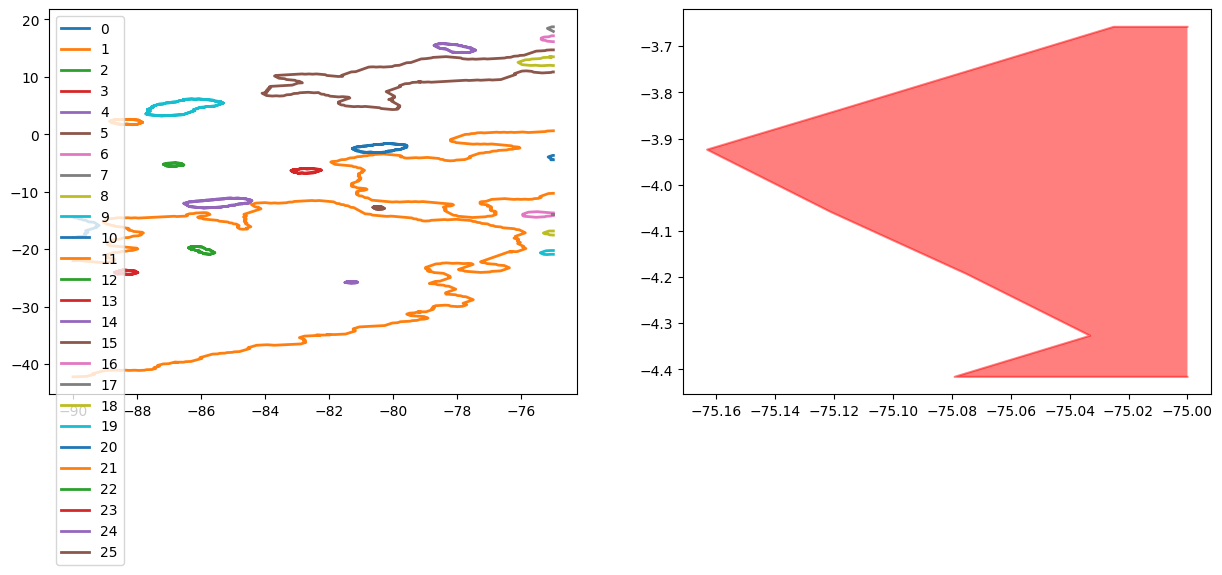

In [21]:
segments = []

for ring in luminosity_levels[1]:
    segments.extend(merge_segments(get_segments(ring, borders=(-90, -75))))

fig, (ax1, ax2) = plt.subplots(ncols = 2, figsize = (15,5))

segments = [*segments, [segments[0][0]]]

for i, segment in enumerate(segments):
    x,y = zip(*segment)
    ax1.plot(x, y, '-', lw=2, label=f'{i}')

shape_rings = join_segs(segments, joins=[[0]], reverse=[6,9,7])
for ring in shape_rings:
    x,y = zip(*ring)
    ax2.fill(x, y, 'r', alpha=0.5)
    ax2.plot(x, y, 'r', alpha=0.5)

ax1.set_aspect('auto')
ax1.legend()
plt.show()

In [16]:
second_shapes.append(shape_rings)

In [17]:
shapes.append(shape_rings)

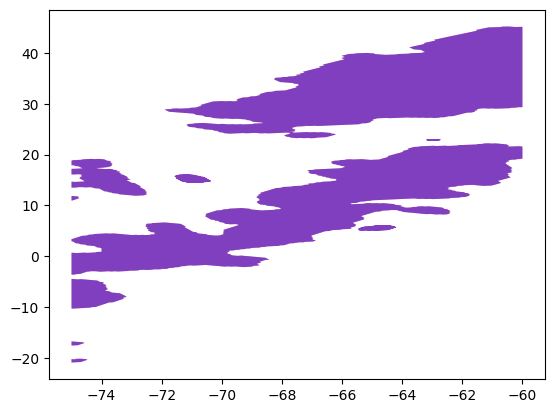

In [18]:
for shape in shapes:
    for ring in shape:
        x,y = zip(*ring)
        plt.fill(x,y, 'r', alpha=0.5)

for shape in second_shapes:
    for ring in shape:
        x,y = zip(*ring)
        plt.fill(x,y, 'b', alpha=0.5)

In [19]:
shapes

[[array([[-60.   ,  29.331],
         [-60.142,  29.331],
         [-60.204,  29.246],
         [-60.363,  29.215],
         [-60.421,  29.13 ],
         [-60.579,  29.098],
         [-60.738,  29.066],
         [-60.896,  29.034],
         [-60.992,  29.087],
         [-61.15 ,  29.054],
         [-61.246,  29.107],
         [-61.404,  29.074],
         [-61.467,  28.989],
         [-61.525,  28.904],
         [-61.488,  28.766],
         [-61.546,  28.681],
         [-61.604,  28.596],
         [-61.567,  28.458],
         [-61.629,  28.373],
         [-61.687,  28.288],
         [-61.842,  28.254],
         [-61.904,  28.169],
         [-61.962,  28.083],
         [-62.021,  27.998],
         [-62.079,  27.912],
         [-62.137,  27.827],
         [-62.196,  27.742],
         [-62.254,  27.656],
         [-62.312,  27.571],
         [-62.467,  27.536],
         [-62.525,  27.451],
         [-62.583,  27.365],
         [-62.738,  27.331],
         [-62.796,  27.245],
         [-62.